# Segmentação K-Means do Comportamento de Assinantes com PROC FASTCLUS

## Resumo Executivo

Este notebook segmenta uma base sintética de 100 assinantes de telefonia móvel em clusters comportamentais usando `PROC FASTCLUS`, o procedimento de clusterização k-means do Base SAS. Sete atributos de uso são padronizados em escores-z com `PROC STDIZE` para que variáveis de alta magnitude (minutos de voz, contagem de SMS) não dominem a distância euclidiana, e então `PROC FASTCLUS` ajusta três clusters. O procedimento reporta o desvio RMS dentro do cluster, um R-quadrado geral e um pseudo-F que quantificam o quão bem a segmentação separa a base (aqui um R-quadrado geral de 0,575 e pseudo-F de 65,75), e grava uma tabela pontuada com um rótulo `CLUSTER` para cada assinante. Unimos esses rótulos de volta aos dados na escala original, traçamos o perfil das personas e entregamos as atribuições para a ativação posterior.

## Fontes de Dados

| Dataset | Descrição | Linhas | Variáveis-chave |
| ------- | ----------- | ---: | ------------- |
| `subscribers` | Instantâneo sintético de comportamento mensal para uma base de assinantes de telecomunicações móveis, gerado inline com `call streaminit` / `rand()`. Três tipos de comportamento latentes (dados intensivos, focado em voz, baixo uso) são combinados com ruído. | 100 | `subscriber_id`, `tenure_months`, `monthly_data_gb`, `voice_minutes`, `sms_count`, `arpu`, `intl_minutes`, `support_calls`, `data_plan` (nominal), `region` (nominal) |

# Segmentação K-Means do Comportamento de Assinantes

**Setor:** Telecomunicações &nbsp;|&nbsp; **Procedimento:** `PROC FASTCLUS` (clusterização k-means do Base SAS)

Operadoras móveis atendem assinantes cujo comportamento mensal -- apetite por dados, hábitos de voz, gasto e atrito no suporte -- se encaixa em um punhado de padrões reconhecíveis. Descobrir esses padrões permite que o negócio personalize ações de retenção, faça upsell dos pacotes certos e adquira clientes semelhantes. Este notebook constrói uma segmentação comportamental de ponta a ponta: gera um instantâneo realista de assinantes, padroniza os atributos, deixa o `PROC FASTCLUS` ajustar os clusters, pontua cada assinante e traça o perfil dos segmentos em personas acionáveis. `PROC FASTCLUS` foi projetado exatamente para essa tarefa de k-means disjunto e escala para bases muito grandes ao percorrer os dados em vez de construir uma matriz de distância completa.

## 1. Gerar uma base sintética de assinantes

Simulamos 100 assinantes extraídos de três arquétipos comportamentais latentes -- **streamers de dados intensivos**, **tradicionalistas focados em voz** e clientes de **uso leve/baixo** -- e então misturamos ruído para que as fronteiras fiquem imprecisas (como são na realidade). Cada assinante também carrega dois atributos categóricos, `data_plan` e `region`, que usamos depois para *traçar o perfil* dos segmentos. A semente torna os dados reproduzíveis.

In [1]:
/* -----------------------------------------------------------
   Instantâneo sintético de assinantes móveis (100 linhas).
   Três arquétipos comportamentais latentes + ruído, mais dois
   atributos categóricos para o perfil dos segmentos.
   ----------------------------------------------------------- */
DADOS subscribers;
    CHAMAR streaminit(20260531);

    COMPRIMENTO data_plan $16 region $12;

    FAZER subscriber_id = 100001 ATÉ 100100;

        /* arquétipo latente: 1=dados intensivos, 2=voz, 3=baixo uso */
        u = rand('uniform');
        SE      u < 0.38 ENTÃO archetype = 1;
        SENÃO SE u < 0.70 ENTÃO archetype = 2;
        SENÃO                  archetype = 3;

        tenure_months = MAX(1, round(rand('gamma', 2.2) * 12));

        SE archetype = 1 ENTÃO FAZER;             /* streamer de dados intensivos */
            monthly_data_gb = MAX(0.5, rand('normal', 42, 11));
            voice_minutes   = MAX(0,   rand('normal', 180, 70));
            sms_count       = MAX(0,   round(rand('normal', 60, 30)));
            intl_minutes    = MAX(0,   rand('normal', 22, 14));
            arpu            = MAX(15,  rand('normal', 78, 14));
            support_calls   = rand('poisson', 0.8);
            planpick = ifn(rand('uniform') < 0.65, 3, 2);
        FIM;
        SENÃO SE archetype = 2 ENTÃO FAZER;        /* focado em voz */
            monthly_data_gb = MAX(0.2, rand('normal', 9, 4));
            voice_minutes   = MAX(0,   rand('normal', 620, 160));
            sms_count       = MAX(0,   round(rand('normal', 210, 80)));
            intl_minutes    = MAX(0,   rand('normal', 95, 45));
            arpu            = MAX(12,  rand('normal', 55, 12));
            support_calls   = rand('poisson', 1.6);
            planpick = ifn(rand('uniform') < 0.55, 2, 1);
        FIM;
        SENÃO FAZER;                              /* baixo uso */
            monthly_data_gb = MAX(0.1, rand('normal', 3, 1.5));
            voice_minutes   = MAX(0,   rand('normal', 110, 50));
            sms_count       = MAX(0,   round(rand('normal', 35, 20)));
            intl_minutes    = MAX(0,   rand('normal', 6, 6));
            arpu            = MAX(8,   rand('normal', 26, 7));
            support_calls   = rand('poisson', 0.5);
            planpick = ifn(rand('uniform') < 0.70, 1, 2);
        FIM;

        SE      planpick = 1 ENTÃO data_plan = 'Pré-pago';
        SENÃO SE planpick = 2 ENTÃO data_plan = 'Pós-pago M';
        SENÃO                       data_plan = 'Ilimitado';

        region_idx = rand('table', 0.30, 0.28, 0.22, 0.20);
        SE      region_idx = 1 ENTÃO region = 'Norte';
        SENÃO SE region_idx = 2 ENTÃO region = 'Sul';
        SENÃO SE region_idx = 3 ENTÃO region = 'Leste';
        SENÃO                         region = 'Oeste';

        /* arredondar para uma precisão de relato organizada */
        monthly_data_gb = round(monthly_data_gb, 0.1);
        voice_minutes   = round(voice_minutes,   1);
        intl_minutes    = round(intl_minutes,    1);
        arpu            = round(arpu,            0.01);

        SAÍDA;
    FIM;

    MANTER subscriber_id tenure_months monthly_data_gb voice_minutes
         sms_count intl_minutes arpu support_calls data_plan region;
EXECUTAR;



NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2. Inspecionar as distribuições dos atributos

Antes de agrupar, observe a escala e a dispersão de cada atributo comportamental. As unidades bem diferentes -- gigabytes, minutos, dólares, contagens -- são exatamente o motivo pelo qual padronizamos os insumos de intervalo antes do agrupamento; caso contrário, variáveis de alta magnitude como `voice_minutes` dominariam a distância euclidiana que o `PROC FASTCLUS` minimiza.

                                                  The MEANS Procedure

 Variable         Label                          N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 -----------------------------------------------------------------------------------------------------------------------------------------------
 tenure_months    Antiguidade (meses)          100        27.6        18.9         3.0             13.0        22.0             37.5        98.0
 monthly_data_gb  Dados Mensais (GB)           100        18.2        18.9         0.1              3.7         9.6             31.5        67.2
 voice_minutes    Minutos de Voz               100       304.2       236.6         0.0            125.0       217.0            527.5       912.0
 sms_count        Qtde. de SMS                 100       102.0       102.6         0.0             35.0        64.0            130.0       404.0
 intl_minutes     Minutos Internacionais       100        4


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_data_plan.spec.json
NOTE: ODS plot written: freq_region.spec.json
NOTE: PROC FREQ statement used.


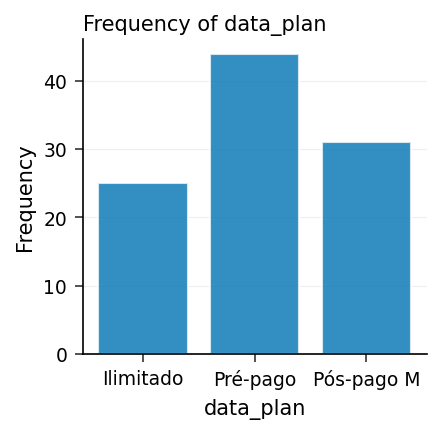

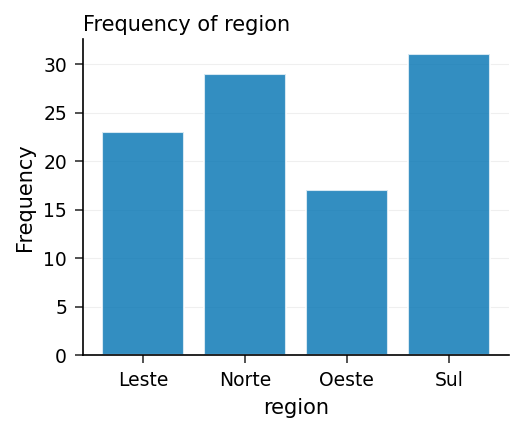

In [2]:
/* Estatísticas descritivas dos insumos de clusterização */
PROCEDIMENTO MÉDIAS DADOS=subscribers n mean std MIN p25 MEDIAN p75 MAX maxdec=1;
    RÓTULO tenure_months="Antiguidade (meses)" monthly_data_gb="Dados Mensais (GB)"
          voice_minutes="Minutos de Voz" sms_count="Qtde. de SMS"
          intl_minutes="Minutos Internacionais" arpu="ARPU (US$)"
          support_calls="Chamadas de Suporte";
    VARIÁVEL tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
EXECUTAR;

/* Frequência dos dois insumos categóricos */
PROCEDIMENTO FREQUÊNCIAS DADOS=subscribers;
    RÓTULO data_plan="Plano de Dados" region="Região";
    TABLES data_plan region / nocum;
EXECUTAR;


## 3. Padronizar os atributos em escores-z

`PROC FASTCLUS` minimiza a distância euclidiana, portanto uma variável medida em centenas de minutos dominaria uma medida em gigabytes de um dígito. `PROC STDIZE` com `METHOD=STD` reescala cada atributo de intervalo para média 0 e desvio padrão 1, dando a cada comportamento peso igual na distância. As colunas categóricas e o identificador passam sem alteração para que possamos traçar o perfil dos clusters em sua escala original depois.

In [3]:
/* padroniza os atributos de intervalo em escores-z; ids e categóricas passam sem alteração */
PROCEDIMENTO stdize DADOS=subscribers out=subs_std METHOD=std;
    VARIÁVEL tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
EXECUTAR;



NOTE: PROC STDIZE data=subscribers

NOTE: PROC STDIZE: Wrote 100 rows to subs_std


## 4. Ajustar a segmentação k-means

Ajustamos três segmentos com `PROC FASTCLUS`. `MAXCLUSTERS=3` define *k*; `MAXITER=20` permite que os centros dos clusters iterem até a convergência. O procedimento reporta um **Resumo dos Clusters** (tamanho e desvio RMS dentro do cluster por cluster), **Estatísticas para Variáveis** (o R-quadrado que cada atributo contribui), um **R-quadrado geral** e **pseudo-F** que medem o quão nitidamente os três clusters se separam na base, e **Médias dos Clusters** na escala padronizada. `OUT=scored` grava as linhas de entrada de volta com um rótulo `CLUSTER` e a `DISTANCE` de cada assinante até a semente do seu cluster.

In [4]:
/* ajuste k-means sobre os atributos padronizados: 3 segmentos. */
PROCEDIMENTO FASTCLUS DADOS=subs_std maxclusters=3 MAXITER=20 out=scored;
    RÓTULO tenure_months="Antiguidade (meses)" monthly_data_gb="Dados Mensais (GB)"
          voice_minutes="Minutos de Voz" sms_count="Qtde. de SMS"
          intl_minutes="Minutos Internacionais" arpu="ARPU (US$)"
          support_calls="Chamadas de Suporte";
    VARIÁVEL tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
EXECUTAR;



                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=20                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  36         0.5293             2.6279              3         3.0809
2                  34         0.7925             3.4184              3         3.5916
3                  30         0.6295             3.9300              1         3.0809

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 7 variables, 3 clusters using k-means


## 5. Anexar os rótulos de segmento aos dados na escala original

A tabela pontuada contém os atributos padronizados; para o perfil queremos os clusters descritos em gigabytes, minutos e dólares reais. Unimos o rótulo `CLUSTER` de volta à tabela `subscribers` original por `subscriber_id`, e então fazemos a primeira pergunta que o marketing sempre faz: *qual o tamanho de cada segmento?*

                                                   The FREQ Procedure

Segmento    Frequency    Percent
---------------------------------
1                  36     36.00
2                  34     34.00
3                  30     30.00



NOTE: PROC SORT data=scored

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from scored.
NOTE: Wrote clus_assign (100 rows, 12 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=subscribers

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from subscribers.
NOTE: Wrote subs_sorted (100 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: DATA profile

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote profile (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_cluster.spec.json
NOTE: PROC FREQ statement used.


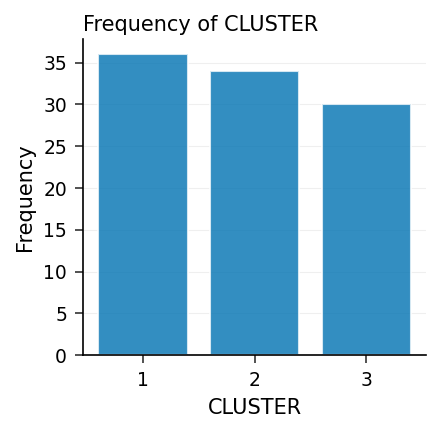

In [5]:
/* leva o rótulo do cluster de volta aos dados na escala original */
PROCEDIMENTO ORDENAR DADOS=scored(MANTER=subscriber_id CLUSTER distance) out=clus_assign;
    POR subscriber_id;
EXECUTAR;
PROCEDIMENTO ORDENAR DADOS=subscribers out=subs_sorted;
    POR subscriber_id;
EXECUTAR;
DADOS profile;
    MESCLAR subs_sorted clus_assign;
    POR subscriber_id;
EXECUTAR;

/* Quantos assinantes caíram em cada segmento? */
PROCEDIMENTO FREQUÊNCIAS DADOS=profile;
    RÓTULO CLUSTER="Segmento";
    TABLES CLUSTER / nocum;
EXECUTAR;


## 6. Traçar o perfil dos segmentos

Os IDs de cluster não têm significado até descrevermos o *comportamento* dentro de cada um. Calcular a média dos atributos originais (não padronizados) por `CLUSTER` revela a persona por trás de cada segmento -- quem faz streaming, quem fala, quem quase não usa a rede -- e a mistura categórica mostra quais planos e regiões se concentram em cada um.

                                                  The MEANS Procedure

                                 Analysis Variable : tenure_months Antiguidade (meses)

        Segmento          N Obs           Mean
        --------------------------------------
        1                    36           28.9
        2                    34           25.8
        3                    30           28.1
        --------------------------------------

                                 Analysis Variable : monthly_data_gb Dados Mensais (GB)

        Segmento          N Obs           Mean
        --------------------------------------
        1                    36            4.0
        2                    34           10.2
        3                    30           44.4
        --------------------------------------

                                    Analysis Variable : voice_minutes Minutos de Voz

        Segmento          N Obs           Mean
        --------------------------------------
      


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_data_plan.spec.json
NOTE: ODS plot written: freq_mosaic_cluster_region.spec.json
NOTE: PROC FREQ statement used.


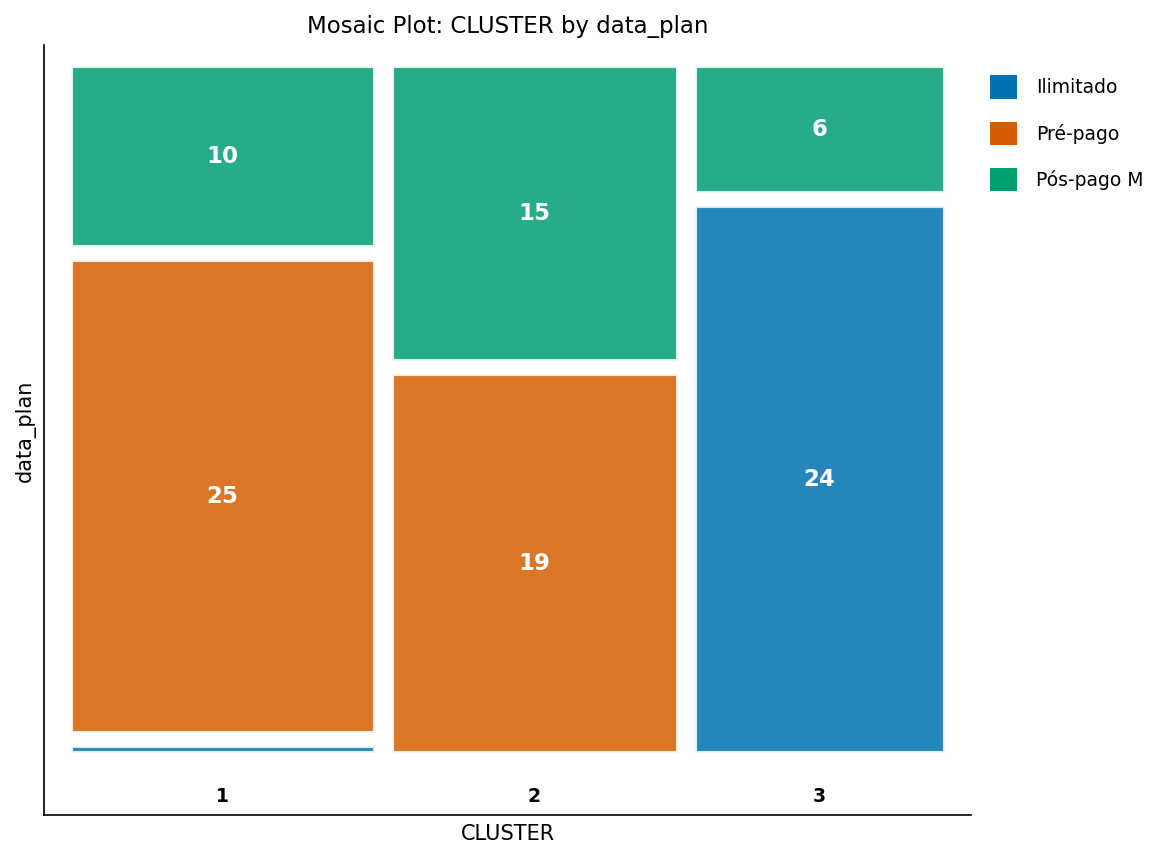

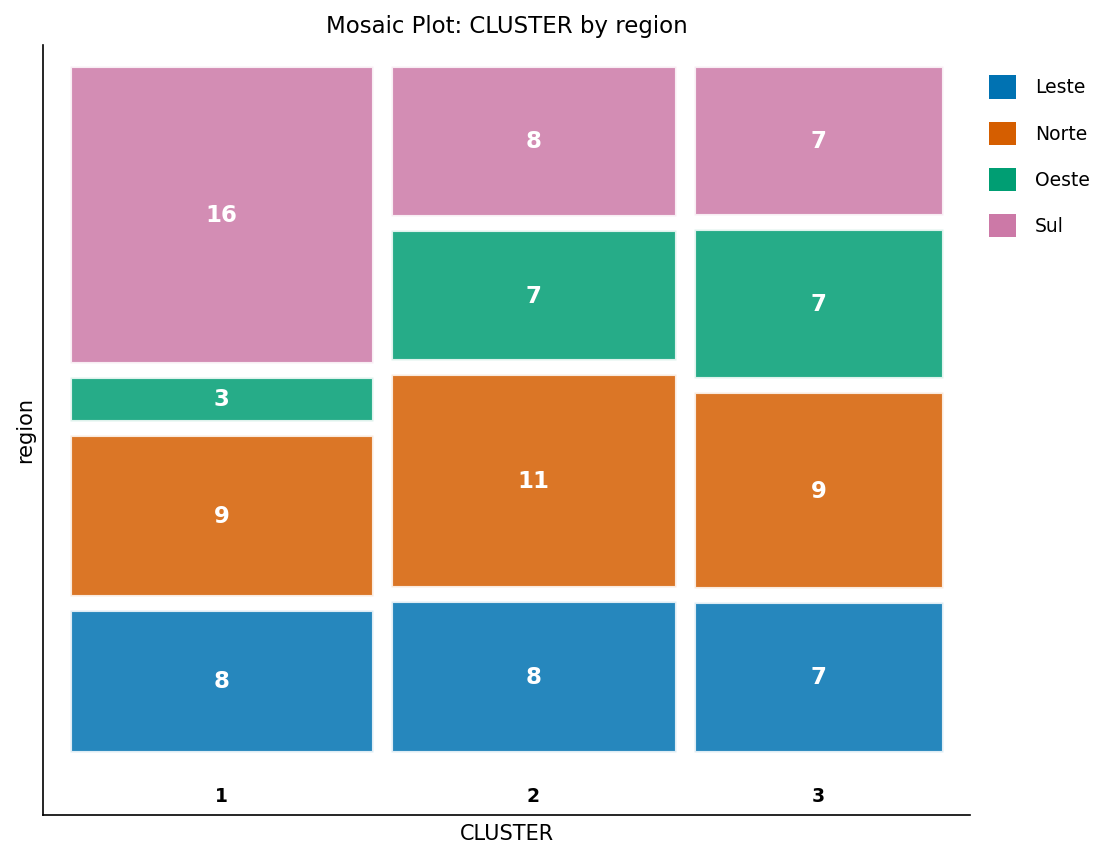

In [6]:
/* Perfil comportamental: média de cada atributo por segmento */
PROCEDIMENTO MÉDIAS DADOS=profile n mean maxdec=1;
    RÓTULO tenure_months="Antiguidade (meses)" monthly_data_gb="Dados Mensais (GB)"
          voice_minutes="Minutos de Voz" sms_count="Qtde. de SMS"
          intl_minutes="Minutos Internacionais" arpu="ARPU (US$)"
          support_calls="Chamadas de Suporte" CLUSTER="Segmento";
    CLASSE CLUSTER;
    VARIÁVEL tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
EXECUTAR;

/* Mistura categórica dentro de cada segmento */
PROCEDIMENTO FREQUÊNCIAS DADOS=profile;
    RÓTULO CLUSTER="Segmento" data_plan="Plano de Dados" region="Região";
    TABLES CLUSTER * data_plan / norow nopercent;
    TABLES CLUSTER * region    / norow nopercent;
EXECUTAR;


## 7. Visualizar os segmentos

Uma imagem torna a segmentação tangível. Plotamos o apetite por dados contra o uso de voz, colorido por segmento, e adicionamos um boxplot do ARPU por segmento para que a história de receita fique óbvia à primeira vista.


NOTE: ODS Graphics is ON (width=720px, height=520px, format=SVG).
NOTE: PROC SGPLOT data=profile

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=profile

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


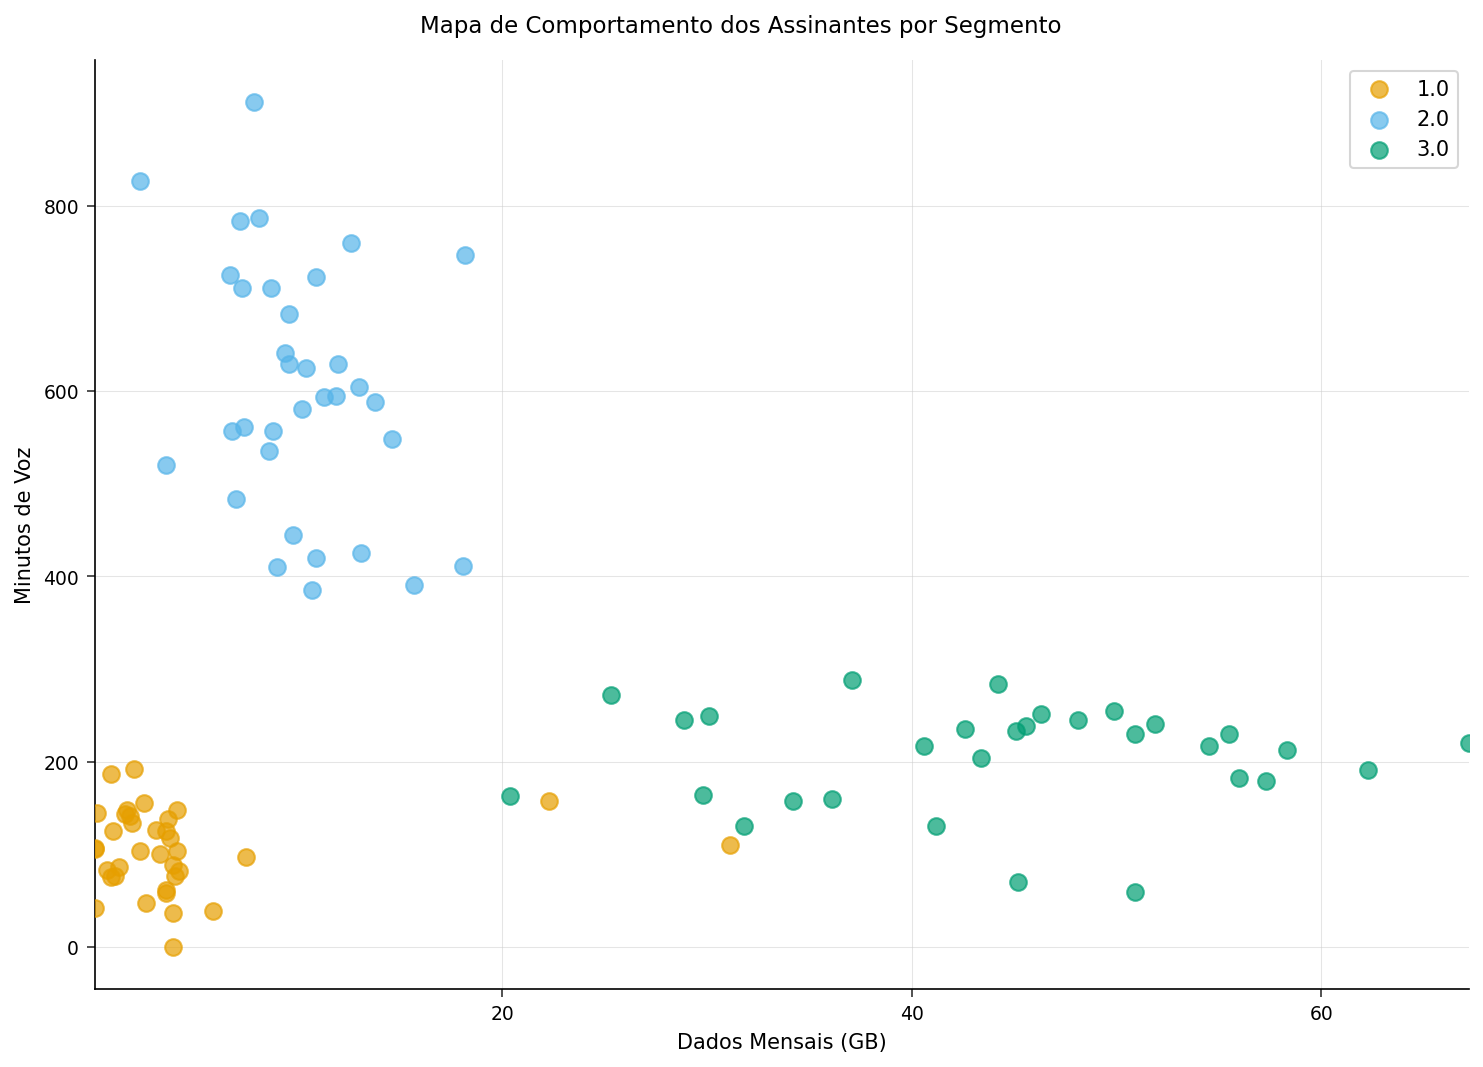

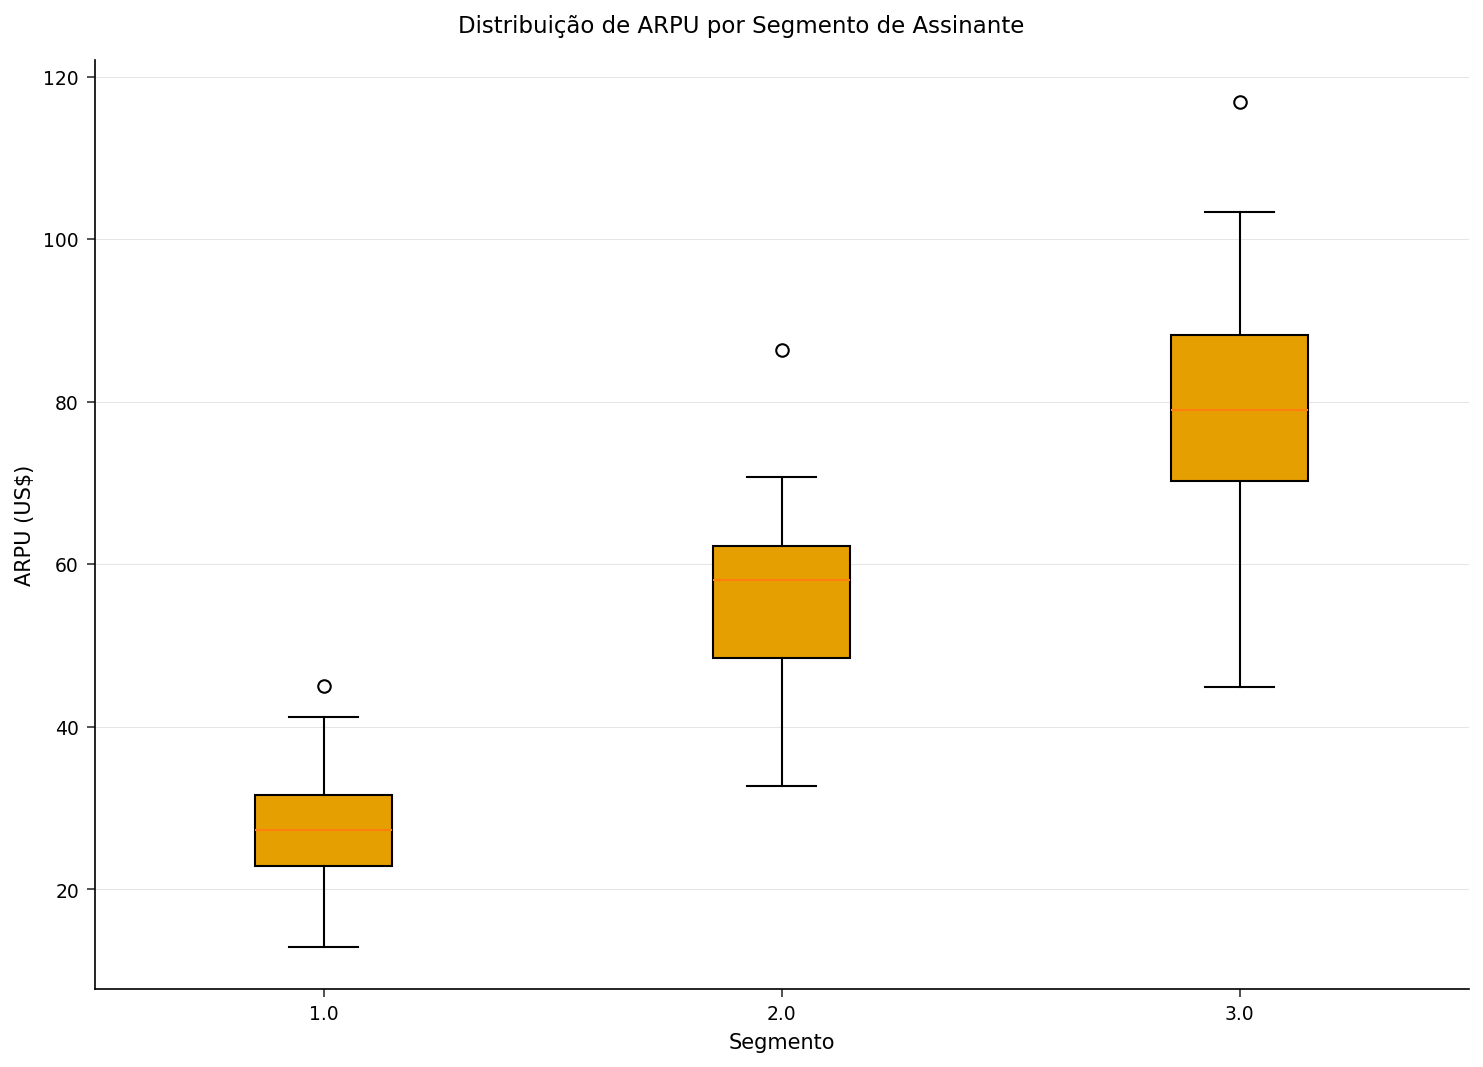

In [7]:
ODS GRAPHICS ON / imagefmt=svg WIDTH=720 HEIGHT=520;

/* Mapa comportamental: dados vs. voz, colorido por segmento */
PROCEDIMENTO SGPLOT DADOS=profile;
    SCATTER x=monthly_data_gb y=voice_minutes
            / GROUP=CLUSTER
              MARKERATTRS=(size=8 SYMBOL=circlefilled)
              TRANSPARENCY=0.3;
    XAXIS RÓTULO='Dados Mensais (GB)' grid;
    YAXIS RÓTULO='Minutos de Voz'     grid;
    TÍTULO 'Mapa de Comportamento dos Assinantes por Segmento';
EXECUTAR;

/* Distribuição de receita por segmento */
PROCEDIMENTO SGPLOT DADOS=profile;
    VBOX arpu / category=CLUSTER;
    XAXIS RÓTULO='Segmento';
    YAXIS RÓTULO='ARPU (US$)' grid;
    TÍTULO 'Distribuição de ARPU por Segmento de Assinante';
EXECUTAR;


## 8. Exportar os segmentos pontuados

Por fim, entregamos as atribuições para os sistemas de CRM e campanha posteriores. Mantemos o identificador, o rótulo de cluster e os principais campos comportamentais.

In [8]:
/* Persiste as atribuições de segmento para ativação */
DADOS subscriber_segments;
    DEFINIR profile;
    MANTER subscriber_id CLUSTER tenure_months
         monthly_data_gb voice_minutes arpu data_plan region;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=subscriber_segments(obs=10) noobs RÓTULO;
    RÓTULO subscriber_id="ID do Assinante" CLUSTER="Segmento"
          tenure_months="Antiguidade (meses)" monthly_data_gb="Dados Mensais (GB)"
          voice_minutes="Minutos de Voz" arpu="ARPU (US$)"
          data_plan="Plano de Dados" region="Região";
    TÍTULO 'Amostra dos Segmentos de Assinantes Pontuados';
EXECUTAR;


                                     Amostra dos Segmentos de Assinantes Pontuados                                      

ID do Assinante  Segmento  Antiguidade (meses)  Dados Mensais (GB)  Minutos de Voz  ARPU (US$)  Plano de Dados   Região
         100001         1                   30                 2.3             104          28  Pré-pago        Sul
         100002         2                    8                10.2             581       57.78  Pré-pago        Oeste
         100003         2                    8                10.7             385       55.66  Pós-pago M      Norte
         100004         2                   68                 7.4             561       70.68  Pré-pago        Norte
         100005         3                   18                45.6             239       63.85  Ilimitado       Norte
         100006         3                   10                30.1             249       88.33  Ilimitado       Leste
         100007         1                   62      


NOTE: DATA subscriber_segments


NOTE: Read 100 rows from profile.
NOTE: Wrote subscriber_segments (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC PRINT data=subscriber_segments

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## Interpretando os resultados

`PROC FASTCLUS` recuperou três segmentos limpos e bem separados. O ajuste é sólido: o **R-quadrado geral é 0,575** e o **pseudo-F é 65,75**, o que significa que os três clusters explicam cerca de 58% da variação total nos atributos padronizados. A separação é impulsionada quase inteiramente pelos sinais comportamentais que importam -- `voice_minutes` (R-quadrado 0,858), `monthly_data_gb` (0,844) e `arpu` (0,771) carregam a segmentação, enquanto `tenure_months` (0,000) e `support_calls` (0,193) contribuem quase nada, confirmando que *como* um assinante usa a rede -- não há quanto tempo ele é cliente -- é o que define as personas.

Os três segmentos mapeiam diretamente para personas prontas para o marketing, com o perfil traçado aqui na escala original (não padronizada):

| Segmento | n (participação) | Comportamento característico | Mistura de planos | Persona | Ação recomendada |
| :-----: | :-------: | ------------------ | -------- | ------- | ---------------- |
| **3** | 30 (30%) | Maior consumo de dados: **44,4 GB/mês**, maior gasto **ARPU de US$ 79,1**, voz moderada (205 min) | 24/30 **Ilimitado** | **Streamers de dados intensivos** | Proteger e fazer upsell: níveis mais rápidos, pacotes de conteúdo, upgrades de aparelho |
| **2** | 34 (34%) | Maior voz **603 min/mês**, **214 SMS**, **106 min internacionais**, gasto médio **ARPU de US$ 55,9** | Pré-pago + Pós-pago M, **sem Ilimitado** | **Tradicionalistas focados em voz** | Complementos internacionais, pacotes familiares/de voz, recompensas de fidelidade |
| **1** | 36 (36%) | Menor uso: **4,0 GB**, 104 min de voz, menor gasto **ARPU de US$ 28,0** | 25/36 **Pré-pago** | **Uso leve/baixo** | Ajustar planos ao tamanho certo, incentivos de débito automático, pacotes de dados de baixo custo para crescer o uso |

A mistura de planos corrobora a leitura comportamental: o segmento de dados intensivos está esmagadoramente em planos **Ilimitados** (24 de 30), o segmento focado em voz **não** tem assinantes Ilimitados, e o segmento de uso leve é majoritariamente **Pré-pago** (25 de 36). A região, por outro lado, está espalhada uniformemente pelos três segmentos -- geografia não é um direcionador comportamental aqui, o que é em si um achado útil para a segmentação de campanhas.

**Por que o `PROC FASTCLUS` se encaixa neste problema.** Ele executa k-means disjunto percorrendo os dados em vez de materializar uma matriz de distância completa, então o mesmo programa que segmentou esses 100 assinantes escala para bases muito maiores. Padronizar com `PROC STDIZE` primeiro removeu o viés de escala de unidade entre gigabytes, minutos e dólares, de modo que cada comportamento contribuiu igualmente para a distância euclidiana; os diagnósticos de R-quadrado então nos disseram *quais* atributos realmente impulsionaram a divisão. A saída pontuada -- um rótulo `CLUSTER` para cada assinante -- entra diretamente em pipelines de ativação, fechando o ciclo do comportamento bruto até a oferta direcionada.

---

<div style="font-size:11px;color:#9e9e9e">Este notebook é fornecido apenas para fins de demonstração. Os dados são sintéticos e as conclusões não constituem aconselhamento de negócios.</div>